# 관세청 수출 주요품목별 10일 단위 잠정치 — 수집 · 예측 · 시각화 (`korea_export_10day_flash_v8`)

**데이터 원천:** 공공데이터포털 「관세청_수출 **주요품목별** 10일 단위 잠정치 통계」 (개발계정 승인, 활용기간 2026-07-15 ~ 2028-07-15, XML/REST)
- **End Point:** `https://apis.data.go.kr/1220000/prlstMmUtPrviExpAcrs` / 상세기능 `/getPrlstMmUtPrviExpAcrs`
- 단위: **천 달러(USD 1,000)** — *단위 불일치 사고 방지를 위해 DB에도 천 달러 그대로 저장*
- 공표 규칙: **1~10일 → 11일 공표 / 1~20일 → 21일 공표 / 1~말일 → 익월 1일 공표**
- 값의 성질: 월내 **누적**(1~10일, 1~20일, 1~말일) / 전월까지 자료는 정정·취하 반영해 **소급 현행화**됨
- 품목: **전체 + 10대 품목** (반도체, 철강제품, 승용차, 석유제품, 무선통신기기, 선박, 자동차부품, 컴퓨터 주변기기, 정밀기기, 가전제품)
- 시간범위: 2016년 1월 ~
- **확인된 응답 스키마 (2026-07-15 실측):** wide 포맷 — `itemUsdAmt00`~`itemUsdAmt10`(11개 품목 컬럼, 콤마/공백 포함 문자열),
  `priodYear`(연), `priodMon`(YYYYMM), `priodDt`(구간, 예: `01~10`) / 기간 파라미터 `strtYymm`/`endYymm` (resultCode 00 확인)

### 파이프라인 (단일 노트북, 위에서 아래로 실행)
1. 경로 설정 (노트북/데스크탑 공용) → 모듈 import → DB 연결
2. API 수집 — `FETCH_MODE`로 제어: **full**(2016-01~최신 전체, 기본) / **incremental**(DB 최신일 기준 자동 증분 + 소급 정정 버퍼) / **manual**(기간 직접 지정). 기간 파라미터는 **필수**이므로 모든 모드에서 전송하며, 조회기간 제한 대응을 위해 **12개월 window로 자동 분할** 요청
3. 정규화(기간/품목/값 자동 탐지, 10일 구간 증분 계산) → `korea_export_10day_flash_by_item` 저장
4. **10일 구간 증분 시계열**(주기 그대로) → SARIMA / ETS / Theta / Ensemble **12개 구간(≈120일) 예측** — 월별 예측은 기존 월간 파이프라인이 담당
5. 예측 결과를 **별도 테이블** `korea_export_10day_flash_by_item_forecast_10d`에 `forecast_date` 구분값으로 저장
6. 시각화: (a) 과거 실적 + 향후 12구간 전망, (b) 과거 예측 빈티지 vs 현재 예측 비교 (모두 10일 주기)

### DB 설계 건의: 예측 결과는 **별도 테이블** (채택안)
| 근거 | 설명 |
|---|---|
| 실적의 소급 현행화 | 이 통계는 잠정치라 실적 자체가 매월 정정됨. 실적 테이블에 예측을 섞으면 "정정된 실적"과 "과거 예측"이 한 테이블에서 구분값으로만 분리되어 조회 실수 위험이 큼 |
| 빈티지 추적 | `(forecast_date, item, target_date, model)` PK로 예측 시점별 이력이 자연스럽게 쌓여, 과거 예측 vs 현재 예측 비교 시각화가 단순 쿼리로 가능 |
| 주기 불일치 | 실적은 10일 주기(누적), 예측은 월간. 한 테이블에 넣으면 주기/의미 혼재 → 기존에 겪은 unit/partial-run 오염과 같은 계열의 리스크 |
| 기존 관례 일치 | `korea_revenue_forecast_result` 등 원천-예측 분리, 버전별 테이블 분리로 PK 충돌 회피해 온 패턴과 동일 |

### 인증키/접속 방식 (자동 fallback 내장)
1. **브라우저형 User-Agent 헤더** 사용 — data.go.kr 게이트웨이 WAF가 `python-requests` 기본 UA를 HTTP 403으로 차단하는 사례가 많음
2. 인증키 적용 방식 fallback: **Encoding 키 URL 직접 결합** → 실패 시 **Decoding 키 requests params 전달**
3. 스킴 fallback: **https** → 실패 시 **http** (총 4가지 조합 자동 시도)
4. 각 시도의 HTTP 상태코드와 응답 본문 앞부분을 로그로 출력해 원인 진단 가능

※ 참고: 활용신청 **승인 직후에는 게이트웨이 반영까지 최대 1시간** 걸릴 수 있습니다. 모든 조합이 403이면
잠시 후 재시도하고, 브라우저에서 아래 진단 셀이 출력하는 URL을 직접 열어 정상 XML이 나오는지 확인하세요
(브라우저는 되고 노트북만 403이면 UA/WAF 문제로 확정).

## 1. 사용자 입력 변수 (이 셀만 수정)

In [1]:
# ==================== 사용자 입력 변수 (필요 시 여기만 수정) ====================

# --- API 설정 (활용신청 승인 정보 반영) ---------------------------------------
# End Point + 상세기능: 수출 주요품목별 10일 단위 잠정치 통계 조회 (개발계정 승인분)
API_URL = "https://apis.data.go.kr/1220000/prlstMmUtPrviExpAcrs/getPrlstMmUtPrviExpAcrs"

# 일반 인증키 — Encoding 키를 1차 사용(URL 직접 결합), 인증 오류 시 Decoding 키로 자동 재시도
SERVICE_KEY_ENCODING = "2o6NG3ixxDgGQ9S4dWUgsMac9WlxfX46%2BJvFRsAlsXQ6xVi6CZewvNJvbHd4S7exkWwt3YWoKSdwvUNb46kSTQ%3D%3D"
SERVICE_KEY_DECODING = "2o6NG3ixxDgGQ9S4dWUgsMac9WlxfX46+JvFRsAlsXQ6xVi6CZewvNJvbHd4S7exkWwt3YWoKSdwvUNb46kSTQ=="

# 페이지네이션 파라미터 (국가 GW 표준)
PAGE_PARAM, ROWS_PARAM = "pageNo", "numOfRows"
ROWS_PER_PAGE = 5000          # 데이터가 소량(전 기간 ~4천행)이라 크게 잡아 1~2회 호출로 끝냄

# --- 수집 기간 제어 -----------------------------------------------------------
# "full"        : 전체 기간 수집 (기본. 최초 적재 및 전체 재검증용 — 최대 분량)
# "incremental" : DB의 최신 stat_date 기준, LOOKBACK_MONTHS만큼 과거부터 재수신
#                 (잠정치 소급 정정 반영 버퍼. 평상시 갱신용 — 수신 시간 최소화)
# "manual"      : 아래 MANUAL_START/END_YYYYMM 구간만 수신
FETCH_MODE = "full"
INCREMENTAL_LOOKBACK_MONTHS = 3      # incremental 모드의 소급 정정 재수신 버퍼(개월)
MANUAL_START_YYYYMM = "202501"       # manual 모드 시작 (YYYYMM)
MANUAL_END_YYYYMM   = None           # manual 모드 종료 (None이면 오늘 기준 최신 공표 구간까지)

# 기간 요청 파라미터 — 이 API는 기간이 "필수"(resultCode 99 확인됨)이므로 모든 모드에서 전송
#   후보 목록을 앞에서부터 자동 탐침(1개월 테스트 요청)해 통하는 이름을 사용.
#   기술문서(docx)에서 정확한 이름 확인 시 맨 앞에 넣으면 탐침 1회로 확정됨.
PERIOD_PARAM_CANDIDATES = [
    ("strtYymm", "endYymm"),        # 관세청 Itemtrade 계열 표준 (가장 유력)
    ("startYymm", "endYymm"),
    ("srchStrtYymm", "srchEndYymm"),
    ("stYymm", "edYymm"),
]
PERIOD_WINDOW_MONTHS = 12            # 조회기간 제한 대응: 12개월 window로 분할 요청 (Itemtrade와 동일 제약 가정)
HIST_START_YYYYMM = "201601"         # 데이터 제공 시작 (2016년 1월 ~)

RETRIES = 3                   # API 재시도 횟수
TIMEOUT = 60                  # API 타임아웃(초)

# --- 응답 스키마 (2026-07-15 실측 확정) ---------------------------------------
PERIOD_MON_COL = "priodMon"      # YYYYMM (예: '202607')
PERIOD_DT_COL  = "priodDt"       # 월내 구간 (예: '01~10', '01~20', '01~31')
ITEM_COL_PREFIX = "itemUsdAmt"   # 품목 컬럼 접두사: itemUsdAmt00 ~ itemUsdAmt10

# 품목 코드 → 품목명 매핑
# ※ 활용신청 상세기능 설명의 나열 순서 기준: "전체, 반도체, 철강제품, 승용차, 석유제품,
#   무선통신기기, 선박, 자동차부품, 컴퓨터 주변기기, 정밀기기, 가전제품"
#   실측값 규모(00=전체 최대, 01=반도체 2위)와 정합 확인됨. 기술문서와 다르면 여기만 수정.
ITEM_NAME_MAP = {
    "itemUsdAmt00": "전체",
    "itemUsdAmt01": "반도체",
    "itemUsdAmt02": "철강제품",
    "itemUsdAmt03": "승용차",
    "itemUsdAmt04": "석유제품",
    "itemUsdAmt05": "무선통신기기",
    "itemUsdAmt06": "선박",
    "itemUsdAmt07": "자동차부품",
    "itemUsdAmt08": "컴퓨터주변기기",
    "itemUsdAmt09": "정밀기기",
    "itemUsdAmt10": "가전제품",
}

# 값의 성질: "auto"면 priodDt의 시작일로 자동 판정 (전부 01~이면 누적 → 증분 자동 계산)
VALUES_ARE_CUMULATIVE = "auto"   # "auto" / True / False

# --- DB 설정 ----------------------------------------------------------------
ACTUAL_TABLE   = "korea_export_10day_flash_by_item"            # 실적(잠정치) 테이블
FORECAST_TABLE = "korea_export_10day_flash_by_item_forecast_10d"  # 10일 주기 예측 테이블 (forecast_date로 구분)
# ※ 이전 버전(v6/v7)에서 월간 예측 테이블(..._forecast)을 이미 생성했다면 별도 테이블이므로 충돌 없음 (필요 시 DROP)

# --- 예측 설정 (10일 주기 그대로 예측 — 월별 예측은 기존 월간 파이프라인 담당) ---
RUN_FORECAST   = True   # False면 수집/저장만 수행
HORIZON        = 12     # 예측 구간 수 (10일 구간 12개 ≈ 120일 ≈ 4개월)
SEASONAL_M     = 36     # 연간 계절주기 = 월 3구간 × 12개월
MIN_OBS        = 108    # 예측에 필요한 최소 관측 구간 수 (36구간 × 3년)
FORECAST_ITEMS = None  # None: 전체 품목 예측 / 리스트 지정 시 해당 품목만 (예: ["반도체", "승용차"])

# --- 시각화 설정 ------------------------------------------------------------
PLOT_YEARS_BACK = 5     # 과거+전망 차트에 표시할 과거 연수

## 2. 경로 설정 (노트북 / 데스크탑 공용)
`DATA` 폴더를 자동 탐색해 프로젝트 루트와 함께 `sys.path`에 추가하고, 실패 시 두 PC의 고정 경로로 fallback합니다.

In [2]:
import sys
import os
from pathlib import Path

# 두 PC의 알려진 DATA 폴더 경로 (fallback용)
KNOWN_DATA_PATHS = [
    r"C:\Users\Hoyoung_Park\PyCharmMiscProject\stock_forecast\DATA",
    r"C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\DATA",
]

def setup_universal_paths():
    """어떤 PC에서도 작동하는 범용 경로 설정: DATA 폴더 자동 탐색 + 고정 경로 fallback"""
    current = Path.cwd()
    # 1) 현재 위치 기준 상위 폴더 자동 탐색
    for parent in [current, *current.parents]:
        data_folder = parent / "DATA"
        if data_folder.exists():
            for p in (str(parent), str(data_folder)):
                if p not in sys.path:
                    sys.path.insert(0, p)
            print(f"[경로 설정] 자동 탐색 성공 | 프로젝트 루트: {parent}")
            print(f"[경로 설정] DATA 폴더: {data_folder}")
            return str(data_folder)
    # 2) 고정 경로 fallback
    for dp in KNOWN_DATA_PATHS:
        if os.path.exists(dp):
            root = str(Path(dp).parent)
            for p in (root, dp):
                if p not in sys.path:
                    sys.path.insert(0, p)
            print(f"[경로 설정] 고정 경로 사용 | 프로젝트 루트: {root}")
            print(f"[경로 설정] DATA 폴더: {dp}")
            return dp
    raise FileNotFoundError(
        f"DATA 폴더를 찾을 수 없습니다.\n현재 위치: {current}\n"
        f"상위 폴더에 DATA 폴더가 있는지, 또는 KNOWN_DATA_PATHS의 경로가 맞는지 확인하세요."
    )

DATA_PATH = setup_universal_paths()

[경로 설정] 자동 탐색 성공 | 프로젝트 루트: C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy
[경로 설정] DATA 폴더: C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\DATA


## 3. Import 및 DB 연결

In [3]:
import logging
import warnings

import requests
import xmltodict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from requests.adapters import HTTPAdapter
from typing import Optional, Dict, List

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")
logger = logging.getLogger(__name__)

# 한글 폰트 (Windows)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# ── 기존 공용 함수 (수정 금지 모듈) ─────────────────────────────────────────
#    ※ 와일드카드 import를 "먼저" 수행한다. stock_invest_function 내부의
#      `import datetime` 등이 같은 이름을 모듈로 덮어써서
#      `datetime.now()` AttributeError를 유발했던 문제(v6)의 원인.
from DATA.stock_invest_function import *  # get_db_host 등
from universal_ts_forecast_function_v2 import (
    forecast_sarima,
    forecast_ets,
    forecast_theta,
)

# ── 이 노트북이 사용하는 핵심 이름들을 star import "이후"에 확정 import ──────
#    (동명 shadowing 방지: datetime/date/time/text 등)
import re
import time
from datetime import date, datetime, timedelta
from calendar import monthrange
from sqlalchemy import create_engine, text

DB_INFO = {
    "host": get_db_host(),
    "port": 3307,
    "user": "stox7412",
    "password": "Apt106503!~",
    "database": "investar",
}

def get_engine_from_info(db_info: dict):
    url = (f"mysql+pymysql://{db_info['user']}:{db_info['password']}"
           f"@{db_info['host']}:{db_info['port']}/{db_info['database']}?charset=utf8mb4")
    return create_engine(url, pool_recycle=3600)

engine = get_engine_from_info(DB_INFO)
with engine.connect() as conn:
    conn.execute(text("SELECT 1"))
print("DB 연결 성공")

DB 연결 성공


## 4. 공표 규칙 기반 최신 구간 계산
날짜를 수동 입력하지 않기 위한 로직입니다. 데이터가 소량이므로 **항상 전체 기간을 수집해 UPSERT**하며
(소급 정정 자동 반영), 이 함수는 "오늘 기준 기대되는 최신 구간"을 계산해 수신 결과와 대조하는
**데이터 최신성 검증**에 사용합니다.

In [4]:
def latest_expected_period(today: Optional[date] = None):
    """
    공표 규칙(1~10일→11일, 1~20일→21일, 1~말일→익월 1일)에 따라
    오늘 기준으로 이미 공표되어 있어야 하는 최신 구간의 (연, 월, 구간종료일)을 반환.
    """
    if today is None:
        today = date.today()
    y, m, d = today.year, today.month, today.day
    if d >= 21:
        return y, m, 20            # 이번 달 1~20일 누적까지 공표됨
    if d >= 11:
        return y, m, 10            # 이번 달 1~10일 누적까지 공표됨
    # 1~10일: 전월 전체(1~말일)까지 공표됨
    py, pm = (y - 1, 12) if m == 1 else (y, m - 1)
    return py, pm, monthrange(py, pm)[1]

def period_end_date(y: int, m: int, seg_day: int) -> date:
    """구간 종료일 → DATE. seg_day가 월말이면 실제 말일로 보정."""
    last = monthrange(y, m)[1]
    return date(y, m, min(seg_day, last))

_exp = latest_expected_period()
print(f"오늘({date.today()}) 기준 기대되는 최신 공표 구간: "
      f"{_exp[0]}년 {_exp[1]}월 1~{_exp[2]}일")

오늘(2026-08-18) 기준 기대되는 최신 공표 구간: 2026년 8월 1~10일


## 5. API 수집 함수 (기간 필수 · 12개월 window 분할 · 파라미터명 자동 탐침 · 인증 fallback)

In [5]:
# 브라우저형 헤더 — data.go.kr WAF가 python-requests 기본 UA를 403으로 차단하는 사례 대응
REQUEST_HEADERS = {
    "User-Agent": ("Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
                   "(KHTML, like Gecko) Chrome/126.0.0.0 Safari/537.36"),
    "Accept": "application/xml, text/xml, */*",
    "Accept-Language": "ko-KR,ko;q=0.9",
}

def make_session() -> requests.Session:
    sess = requests.Session()
    sess.headers.update(REQUEST_HEADERS)
    adapter = HTTPAdapter(pool_connections=4, pool_maxsize=4)
    sess.mount("https://", adapter)
    sess.mount("http://", adapter)
    return sess

def _parse_response(response_text: str):
    """XML 응답 → (items DataFrame, totalCount, resultCode, resultMsg)"""
    try:
        parsed = xmltodict.parse(response_text)
    except Exception:
        return pd.DataFrame(), None, None, None
    resp = parsed.get("response") if isinstance(parsed, dict) else None
    if not isinstance(resp, dict):
        return pd.DataFrame(), None, None, None
    header = resp.get("header") or {}
    body = resp.get("body") or {}
    code_, msg = header.get("resultCode"), header.get("resultMsg")
    total = body.get("totalCount")
    items = body.get("items")
    item = items.get("item") if isinstance(items, dict) else None
    if item is None:
        return pd.DataFrame(), total, code_, msg
    if isinstance(item, dict):
        item = [item]
    return pd.DataFrame(item), total, code_, msg

_AUTH_ERR_CODES = {"30", "31", "32", "33"}  # 등록되지 않은 키/사용중지/기한만료/등록되지 않은 IP 등

def _request_page(sess, page: int, period_start: str, period_end: str,
                  param_names: tuple):
    """
    단일 페이지 요청 — 4가지 접속 조합 자동 fallback:
      (1) https + Encoding 키 URL 직접 결합
      (2) https + Decoding 키 params 전달
      (3) http  + Encoding 키 URL 직접 결합
      (4) http  + Decoding 키 params 전달
    401/403/404는 재시도 없이 즉시 다음 조합으로 넘어가고, 상태코드/본문을 로그로 남긴다.
    param_names: (start_name, end_name) — 기간 파라미터는 이 API에서 필수.
    """
    start_name, end_name = param_names
    common = {PAGE_PARAM: page, ROWS_PARAM: ROWS_PER_PAGE,
              start_name: period_start, end_name: period_end}
    qs = "&".join(f"{k}={v}" for k, v in common.items())

    attempts = []
    for scheme_url in (API_URL, API_URL.replace("https://", "http://", 1)):
        attempts.append(("enc-in-url  | " + scheme_url.split("://")[0], None,
                         f"{scheme_url}?serviceKey={SERVICE_KEY_ENCODING}&{qs}"))
        attempts.append(("dec-in-param| " + scheme_url.split("://")[0],
                         dict(common, serviceKey=SERVICE_KEY_DECODING), scheme_url))

    last_err = None
    for mode, params, url in attempts:
        for attempt in range(RETRIES):
            try:
                r = sess.get(url, params=params, timeout=TIMEOUT)
            except requests.exceptions.RequestException as e:
                last_err = e
                time.sleep(2 ** attempt)
                continue

            if r.status_code in (429, 502, 503, 504):
                time.sleep(2 ** attempt)
                continue
            if r.status_code in (401, 403, 404):
                body_head = (r.text or "").strip()[:300]
                print(f"  [차단] {mode} → HTTP {r.status_code} | 본문: {body_head!r}")
                last_err = f"HTTP {r.status_code} ({mode})"
                break  # 같은 조합 재시도 무의미 → 다음 조합
            if not r.ok:
                last_err = f"HTTP {r.status_code} ({mode})"
                time.sleep(2 ** attempt)
                continue

            df, total, code_, msg = _parse_response(r.text)
            if code_ is not None and str(code_).strip() in _AUTH_ERR_CODES:
                print(f"  [인증 fallback] {mode} 실패 (resultCode={code_}, msg={msg}) → 다음 조합")
                break
            if df.empty and "SERVICE" in (r.text or "").upper() and "KEY" in (r.text or "").upper() \
                    and total is None:
                print(f"  [인증 fallback] {mode} 실패 (SERVICE KEY 오류 응답) → 다음 조합")
                break
            if params is None:
                print(f"  [접속 성공] {mode}")
            else:
                print(f"  [접속 성공] {mode}")
            return df, total, code_, msg, r.text
        else:
            continue
    raise RuntimeError(
        f"API 호출 실패 (page {page}): 4가지 접속 조합 모두 실패. 마지막 오류: {last_err}\n"
        f"  → 아래 진단 셀의 URL을 브라우저에서 직접 열어 보세요.\n"
        f"  → 승인 직후라면 게이트웨이 반영까지 최대 1시간 대기 후 재시도."
    )

def resolve_fetch_range():
    """FETCH_MODE에 따라 (start_yyyymm, end_yyyymm) 결정. 기간 파라미터는 필수라 full도 명시 범위 사용."""
    ey, em, _ = latest_expected_period()
    latest_yymm = f"{ey:04d}{em:02d}"

    if FETCH_MODE == "full":
        return HIST_START_YYYYMM, latest_yymm
    if FETCH_MODE == "manual":
        end = MANUAL_END_YYYYMM or latest_yymm
        return MANUAL_START_YYYYMM, end
    if FETCH_MODE == "incremental":
        try:
            with engine.connect() as conn:
                max_dt = conn.execute(text(f"SELECT MAX(stat_date) FROM {ACTUAL_TABLE}")).scalar()
        except Exception:
            max_dt = None
        if max_dt is None:
            print("[incremental] 기존 데이터 없음 → full 수집으로 전환")
            return HIST_START_YYYYMM, latest_yymm
        base = pd.Timestamp(max_dt) - pd.DateOffset(months=INCREMENTAL_LOOKBACK_MONTHS)
        return f"{base.year:04d}{base.month:02d}", latest_yymm
    raise ValueError(f"알 수 없는 FETCH_MODE: {FETCH_MODE}")

def _yymm_to_int(yymm: str) -> int:
    return int(yymm[:4]) * 12 + (int(yymm[4:6]) - 1)

def _int_to_yymm(m: int) -> str:
    return f"{m // 12:04d}{(m % 12) + 1:02d}"

def split_into_windows(start_yymm: str, end_yymm: str, months: int = PERIOD_WINDOW_MONTHS):
    """[start, end] (포함)를 최대 months개월 window 리스트로 분할 (조회기간 제한 대응)"""
    s, e = _yymm_to_int(start_yymm), _yymm_to_int(end_yymm)
    if e < s:
        raise ValueError(f"end({end_yymm}) < start({start_yymm})")
    wins, cur = [], s
    while cur <= e:
        we = min(cur + months - 1, e)
        wins.append((_int_to_yymm(cur), _int_to_yymm(we)))
        cur = we + 1
    return wins

def probe_period_param_names(sess) -> tuple:
    """
    기간 파라미터 이름 자동 탐침: 후보별로 1개월 테스트 요청을 보내
    resultCode 99(필수 요청변수 누락)가 아닌 응답이 나오는 첫 후보를 채택.
    """
    ey, em, _ = latest_expected_period()
    test_yymm = f"{ey:04d}{em:02d}"
    for cand in PERIOD_PARAM_CANDIDATES:
        try:
            df, total, code_, msg, _raw = _request_page(sess, 1, test_yymm, test_yymm, cand)
        except RuntimeError as e:
            print(f"  [탐침] {cand}: 접속 실패 → {e}")
            continue
        code_s = str(code_).strip() if code_ is not None else None
        if code_s == "99":
            print(f"  [탐침] {cand}: resultCode 99 (파라미터명 불일치) → 다음 후보")
            continue
        print(f"  [탐침 성공] 기간 파라미터명 = {cand} (resultCode={code_s}, {len(df)}행)")
        return cand
    raise RuntimeError(
        "기간 파라미터명 후보가 모두 resultCode 99로 거부되었습니다.\n"
        "  → 데이터셋 페이지의 기술문서(docx) 또는 미리보기(확인 버튼)에서 정확한 파라미터명을 확인해\n"
        "    Cell 2의 PERIOD_PARAM_CANDIDATES 맨 앞에 추가하세요."
    )

def fetch_flash_data() -> pd.DataFrame:
    """
    FETCH_MODE에 따라 수집 (기간 파라미터 필수):
      full        → 2016-01 ~ 오늘 기준 최신 공표월 (최대 분량, 기본)
      incremental → DB 최신일 - LOOKBACK부터 (평상시 갱신, 수신 시간 최소화)
      manual      → 지정 구간
    조회기간 제한 대응을 위해 PERIOD_WINDOW_MONTHS 단위로 분할 요청하고,
    각 window 안에서 페이지네이션을 수행한다.
    """
    start_yymm, end_yymm = resolve_fetch_range()
    windows = split_into_windows(start_yymm, end_yymm)
    print(f"[수집 모드] {FETCH_MODE} | 요청 구간: {start_yymm} ~ {end_yymm} "
          f"({len(windows)}개 window × 최대 {PERIOD_WINDOW_MONTHS}개월)")

    sess = make_session()
    param_names = probe_period_param_names(sess)

    dfs = []
    for wi, (ws, we) in enumerate(windows, 1):
        page = 1
        w_rows = 0
        while True:
            df, total, code_, msg, raw = _request_page(sess, page, ws, we, param_names)
            if df.empty:
                if page == 1 and str(code_).strip() not in ("0", "00", "None"):
                    print(f"  window {wi} ({ws}~{we}): 데이터 없음 (resultCode={code_}, msg={msg})")
                break
            dfs.append(df)
            w_rows += len(df)
            try:
                if total is not None and w_rows >= int(total):
                    break
            except (TypeError, ValueError):
                pass
            if len(df) < ROWS_PER_PAGE:
                break
            page += 1
        print(f"  window {wi}/{len(windows)} ({ws}~{we}): {w_rows:,}행")

    if not dfs:
        return pd.DataFrame()
    out = pd.concat(dfs, ignore_index=True)
    out.attrs["fetch_range"] = (start_yymm, end_yymm)
    print(f"수집 완료: 총 {len(out):,}행, 컬럼 {list(out.columns)}")
    return out

## 5-1. 접속 진단 (403 등 차단 시 사용)
아래 셀은 단일 요청을 보내 HTTP 상태코드·응답 헤더·본문 앞부분을 그대로 출력하고,
브라우저에서 직접 열어볼 수 있는 테스트 URL을 함께 표시합니다.
- **브라우저에서는 정상 XML인데 노트북만 403** → WAF의 UA 차단 (v4의 브라우저형 헤더로 해결되는지 확인)
- **브라우저에서도 403/오류** → 승인 반영 대기(최대 1시간) 또는 활용신청 상태 확인

In [6]:
def diagnose_connection():
    ey, em, _ = latest_expected_period()
    yymm = f"{ey:04d}{em:02d}"
    sn, en = PERIOD_PARAM_CANDIDATES[0]
    test_url = (f"{API_URL}?serviceKey={SERVICE_KEY_ENCODING}"
                f"&{PAGE_PARAM}=1&{ROWS_PARAM}=5&{sn}={yymm}&{en}={yymm}")
    print("[브라우저 테스트용 URL]")
    print(test_url)
    print("-" * 100)
    sess = make_session()
    try:
        r = sess.get(test_url, timeout=TIMEOUT)
        print(f"HTTP {r.status_code}")
        print(f"응답 헤더 Server/Content-Type: {r.headers.get('Server')} / {r.headers.get('Content-Type')}")
        print(f"본문 앞 800자:\n{(r.text or '')[:800]}")
    except Exception as e:
        print(f"요청 예외: {e}")

diagnose_connection()

[브라우저 테스트용 URL]
https://apis.data.go.kr/1220000/prlstMmUtPrviExpAcrs/getPrlstMmUtPrviExpAcrs?serviceKey=2o6NG3ixxDgGQ9S4dWUgsMac9WlxfX46%2BJvFRsAlsXQ6xVi6CZewvNJvbHd4S7exkWwt3YWoKSdwvUNb46kSTQ%3D%3D&pageNo=1&numOfRows=5&strtYymm=202608&endYymm=202608
----------------------------------------------------------------------------------------------------
HTTP 200
응답 헤더 Server/Content-Type: None / application/xml
본문 앞 800자:
<?xml version="1.0" encoding="UTF-8" standalone="yes"?><response><header><resultCode>00</resultCode><resultMsg>정상서비스.</resultMsg></header><body><items><item><itemUsdAmt00>          21,285,723</itemUsdAmt00><itemUsdAmt01>           9,951,784</itemUsdAmt01><itemUsdAmt02>             900,708</itemUsdAmt02><itemUsdAmt03>             181,589</itemUsdAmt03><itemUsdAmt04>           1,997,215</itemUsdAmt04><itemUsdAmt05>             470,569</itemUsdAmt05><itemUsdAmt06>             470,680</itemUsdAmt06><itemUsdAmt07>             223,664</itemUsdAmt07><itemUsdAmt08>             58

## 6. 수집 실행 및 원본 확인 (연결 테스트)

In [7]:
df_raw = fetch_flash_data()

if df_raw.empty:
    raise RuntimeError(
        "수신 데이터가 없습니다. 위 경고의 resultCode/resultMsg와 응답 원문을 확인하세요.\n"
        " - 인증 오류: Encoding/Decoding 두 방식 모두 실패한 경우 활용신청 승인 상태 확인\n"
        " - resultCode 99 지속: 기술문서(docx)의 기간 파라미터명을 PERIOD_PARAM_CANDIDATES 맨 앞에 추가\n"
        " - incremental/manual 모드에서 빈 응답이면 FETCH_MODE='full'로 1회 확인"
    )

print("\n[원본 미리보기 — 스키마 변경 감지 시 이 출력을 참고]")
print(df_raw.head(6).to_string())
print("\n[dtypes]")
print(df_raw.dtypes)

[수집 모드] full | 요청 구간: 201601 ~ 202608 (11개 window × 최대 12개월)
  [접속 성공] enc-in-url  | https
  [탐침 성공] 기간 파라미터명 = ('strtYymm', 'endYymm') (resultCode=00, 1행)
  [접속 성공] enc-in-url  | https
  window 1/11 (201601~201612): 36행
  [접속 성공] enc-in-url  | https
  window 2/11 (201701~201712): 36행
  [접속 성공] enc-in-url  | https
  window 3/11 (201801~201812): 36행
  [접속 성공] enc-in-url  | https
  window 4/11 (201901~201912): 36행
  [접속 성공] enc-in-url  | https
  window 5/11 (202001~202012): 36행
  [접속 성공] enc-in-url  | https
  window 6/11 (202101~202112): 36행
  [접속 성공] enc-in-url  | https
  window 7/11 (202201~202212): 36행
  [접속 성공] enc-in-url  | https
  window 8/11 (202301~202312): 36행
  [접속 성공] enc-in-url  | https
  window 9/11 (202401~202412): 36행
  [접속 성공] enc-in-url  | https
  window 10/11 (202501~202512): 36행
  [접속 성공] enc-in-url  | https
  window 11/11 (202601~202608): 22행
수집 완료: 총 382행, 컬럼 ['itemUsdAmt00', 'itemUsdAmt01', 'itemUsdAmt02', 'itemUsdAmt03', 'itemUsdAmt04', 'itemUsdAmt05', 'itemUsdAmt0

## 7. 정규화: 실측 스키마 기반 파싱 → long 포맷 → 10일 구간 증분 계산
- `priodMon`(YYYYMM) + `priodDt`(예: `01~10`)로 구간 종료일(`stat_date`)과 segment(D10/D20/EOM) 결정
- `itemUsdAmt00~10` wide 컬럼을 `ITEM_NAME_MAP`으로 melt (콤마/공백 제거 후 정수 변환)
- 누적 여부는 `priodDt` 시작일로 자동 판정: 전 구간이 `01~`이면 **월내 누적** → 증분 자동 분해
- 검증 출력: 완결월에서 EOM 누적 = 증분 합 일치 여부
- FETCH_MODE가 incremental/manual이면 클라이언트 측 구간 필터를 한 번 더 적용

In [8]:
_PRIOD_DT_RE = re.compile(r"^\s*(\d{1,2})\s*~\s*(\S+)\s*$")   # '01~10', '01~말일' 등

def _parse_priod_dt(val, year: int, month: int):
    """priodDt → (구간시작일, 구간종료일). 종료가 숫자가 아니면(예: 말일) 실제 말일로 처리."""
    m_ = _PRIOD_DT_RE.match(str(val))
    if not m_:
        return None
    d1 = int(m_.group(1))
    d2_raw = m_.group(2)
    if d2_raw.isdigit():
        d2 = int(d2_raw)
    else:
        d2 = monthrange(year, month)[1]   # '말일' 류 표기
    return d1, min(d2, monthrange(year, month)[1])

def _seg_from_day(d: int) -> str:
    if d <= 10:
        return "D10"
    if d <= 20:
        return "D20"
    return "EOM"

def _clean_amount(series: pd.Series) -> pd.Series:
    """'          29,839,145' → 29839145 (콤마·공백 제거)"""
    return pd.to_numeric(
        series.astype(str).str.replace(",", "", regex=False).str.strip(),
        errors="coerce",
    )

def normalize_flash_df(df_in: pd.DataFrame) -> pd.DataFrame:
    """실측 스키마 파싱 → [stat_date, year, month, segment, item_name, exp_dlr_cum, exp_dlr_inc]"""
    df = df_in.copy()

    # ---- 필수 컬럼 확인 ----
    item_cols = sorted([c for c in df.columns if str(c).startswith(ITEM_COL_PREFIX)])
    missing = [c for c in (PERIOD_MON_COL, PERIOD_DT_COL) if c not in df.columns]
    if missing or not item_cols:
        raise ValueError(
            f"응답 스키마가 예상과 다릅니다. 누락: {missing}, 품목 컬럼: {item_cols}\n"
            f"수신 컬럼 전체: {list(df.columns)}"
        )
    unmapped = [c for c in item_cols if c not in ITEM_NAME_MAP]
    if unmapped:
        print(f"[경고] ITEM_NAME_MAP에 없는 품목 컬럼 {unmapped} → 컬럼명 그대로 사용")

    # ---- 기간 파싱 ----
    df["year"] = pd.to_numeric(df[PERIOD_MON_COL].astype(str).str[:4], errors="coerce")
    df["month"] = pd.to_numeric(df[PERIOD_MON_COL].astype(str).str[4:6], errors="coerce")
    ok = df["year"].notna() & df["month"].notna()
    if (~ok).any():
        print(f"[경고] priodMon 파싱 불가 {int((~ok).sum())}행 제외")
    df = df.loc[ok].copy()
    df["year"] = df["year"].astype(int)
    df["month"] = df["month"].astype(int)

    seg_parsed = df.apply(lambda r: _parse_priod_dt(r[PERIOD_DT_COL], r["year"], r["month"]), axis=1)
    ok2 = seg_parsed.notna()
    if (~ok2).any():
        print(f"[경고] priodDt 파싱 불가 {int((~ok2).sum())}행 제외 "
              f"(예: {df.loc[~ok2, PERIOD_DT_COL].astype(str).head(3).tolist()})")
    df = df.loc[ok2].copy()
    df["_d_start"] = seg_parsed[ok2].map(lambda t: t[0])
    df["_d_end"] = seg_parsed[ok2].map(lambda t: t[1])
    df["segment"] = df["_d_end"].map(_seg_from_day)
    df["stat_date"] = df.apply(lambda r: date(int(r["year"]), int(r["month"]), int(r["_d_end"])), axis=1)

    # ---- 누적 여부 자동 판정 ----
    if VALUES_ARE_CUMULATIVE == "auto":
        cumulative = bool((df["_d_start"] == 1).all())
        print(f"[판정] priodDt 시작일 전수 검사 → 값의 성질: "
              f"{'월내 누적 (전 구간 01~)' if cumulative else '구간 증분 (시작일 01/11/21 혼재)'}")
    else:
        cumulative = bool(VALUES_ARE_CUMULATIVE)
        print(f"[설정] VALUES_ARE_CUMULATIVE={cumulative} (수동 지정)")

    # ---- wide → long ----
    for c in item_cols:
        df[c] = _clean_amount(df[c])
    long_df = df.melt(
        id_vars=["stat_date", "year", "month", "segment"],
        value_vars=item_cols, var_name="_item_col", value_name="val",
    )
    long_df["item_name"] = long_df["_item_col"].map(lambda c: ITEM_NAME_MAP.get(c, c))
    long_df = long_df.dropna(subset=["val"])

    # 동일 (stat_date, item) 중복 시 마지막 값 유지 (소급 정정 대비)
    long_df = (long_df.sort_values(["item_name", "stat_date"])
                      .drop_duplicates(subset=["stat_date", "item_name"], keep="last"))

    # ---- 누적 ↔ 증분 ----
    seg_order = {"D10": 1, "D20": 2, "EOM": 3}
    long_df["_seg_no"] = long_df["segment"].map(seg_order)
    long_df = long_df.sort_values(["item_name", "year", "month", "_seg_no"])
    if cumulative:
        long_df["exp_dlr_cum"] = long_df["val"].round().astype("int64")
        prev = long_df.groupby(["item_name", "year", "month"])["exp_dlr_cum"].shift(1)
        long_df["exp_dlr_inc"] = (long_df["exp_dlr_cum"] - prev.fillna(0)).round().astype("int64")
        neg = long_df["exp_dlr_inc"] < 0
        if neg.any():
            print(f"[경고] 증분 음수 {int(neg.sum())}행 — 누적 가정 재검토 필요 "
                  f"(VALUES_ARE_CUMULATIVE=False로 수동 지정 후 비교)")
    else:
        long_df["exp_dlr_inc"] = long_df["val"].round().astype("int64")
        long_df["exp_dlr_cum"] = (long_df.groupby(["item_name", "year", "month"])["exp_dlr_inc"]
                                          .cumsum().round().astype("int64"))
    long_df = long_df.drop(columns=["_seg_no", "_item_col", "val"])

    out = long_df[["stat_date", "year", "month", "segment", "item_name",
                   "exp_dlr_cum", "exp_dlr_inc"]].reset_index(drop=True)

    # ---- 검증: 완결월에서 EOM 누적 == 증분 합 ----
    chk = out.groupby(["item_name", "year", "month"]).agg(
        n_seg=("segment", "nunique"),
        inc_sum=("exp_dlr_inc", "sum"),
        eom_cum=("exp_dlr_cum", "max"),
    )
    full = chk[chk["n_seg"] == 3]
    bad = full[full["inc_sum"] != full["eom_cum"]]
    print(f"[검증] 3구간 완결월 {len(full):,}건 중 누적-증분 불일치 {len(bad):,}건")
    if len(bad):
        print(bad.head(5))

    # ---- 클라이언트 측 구간 필터 (서버 응답과 무관하게 DB 갱신 범위 보장) ----
    rng = getattr(df_in, "attrs", {}).get("fetch_range", (None, None))
    s_yymm, e_yymm = rng
    if s_yymm or e_yymm:
        before = len(out)
        ym = out["year"] * 100 + out["month"]
        if s_yymm:
            out = out[ym >= int(s_yymm)]
        if e_yymm:
            ym = out["year"] * 100 + out["month"]
            out = out[ym <= int(e_yymm)]
        out = out.reset_index(drop=True)
        print(f"[구간 필터] {s_yymm or '처음'} ~ {e_yymm or '끝'} 적용: {before:,} → {len(out):,}행")
    return out

df_flash = normalize_flash_df(df_raw)
print(f"\n정규화 완료: {len(df_flash):,}행, 품목 {df_flash['item_name'].nunique()}개")
print("품목 목록:", sorted(df_flash["item_name"].unique().tolist()))
print(df_flash.tail(12).to_string())

[판정] priodDt 시작일 전수 검사 → 값의 성질: 월내 누적 (전 구간 01~)
[검증] 3구간 완결월 1,397건 중 누적-증분 불일치 0건
[구간 필터] 201601 ~ 202608 적용: 4,202 → 4,202행

정규화 완료: 4,202행, 품목 11개
품목 목록: ['가전제품', '무선통신기기', '반도체', '석유제품', '선박', '승용차', '자동차부품', '전체', '정밀기기', '철강제품', '컴퓨터주변기기']
       stat_date  year  month segment item_name  exp_dlr_cum  exp_dlr_inc
4190  2026-04-20  2026      4     D20   컴퓨터주변기기      2197612      1674639
4191  2026-04-30  2026      4     EOM   컴퓨터주변기기      4238499      2040887
4192  2026-05-10  2026      5     D10   컴퓨터주변기기       627104       627104
4193  2026-05-20  2026      5     D20   컴퓨터주변기기      2449292      1822188
4194  2026-05-31  2026      5     EOM   컴퓨터주변기기      4337680      1888388
4195  2026-06-10  2026      6     D10   컴퓨터주변기기       928331       928331
4196  2026-06-20  2026      6     D20   컴퓨터주변기기      3065605      2137274
4197  2026-06-30  2026      6     EOM   컴퓨터주변기기      5584367      2518762
4198  2026-07-10  2026      7     D10   컴퓨터주변기기       874143       874143
4199  2026-07

## 8. 실적 테이블 저장 (UPSERT — 소급 정정 자동 반영) + 최신성 검증
incremental/manual 모드에서도 UPSERT라 기존 데이터와 충돌 없이 해당 구간만 갱신됩니다.

In [12]:
DDL_ACTUAL = f"""
CREATE TABLE IF NOT EXISTS {ACTUAL_TABLE} (
    stat_date    DATE         NOT NULL COMMENT '구간 종료일 (10일/20일/말일)',
    year         INT          NOT NULL,
    month        INT          NOT NULL,
    segment      VARCHAR(3)   NOT NULL COMMENT 'D10=1~10일, D20=1~20일, EOM=1~말일',
    item_name    VARCHAR(50)  NOT NULL COMMENT '품목명 (전체 포함: 전체, 반도체, 철강제품, 승용차, ...)',
    exp_dlr_cum  BIGINT       NOT NULL COMMENT '월내 누적 수출금액 (천 달러)',
    exp_dlr_inc  BIGINT       NOT NULL COMMENT '10일 구간 증분 수출금액 (천 달러)',
    collected_at DATETIME     NOT NULL COMMENT '수집 시각',
    PRIMARY KEY (stat_date, item_name)
) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4
"""

UPSERT_ACTUAL = text(f"""
INSERT INTO {ACTUAL_TABLE}
    (stat_date, year, month, segment, item_name, exp_dlr_cum, exp_dlr_inc, collected_at)
VALUES
    (:stat_date, :year, :month, :segment, :item_name, :exp_dlr_cum, :exp_dlr_inc, :collected_at)
ON DUPLICATE KEY UPDATE
    exp_dlr_cum = VALUES(exp_dlr_cum),
    exp_dlr_inc = VALUES(exp_dlr_inc),
    segment     = VALUES(segment),
    collected_at = VALUES(collected_at)
""")

def save_actuals(df: pd.DataFrame):
    now = datetime.now()
    rows = df.to_dict("records")
    for r in rows:
        r["collected_at"] = now
    with engine.begin() as conn:
        conn.execute(text(DDL_ACTUAL))
        CHUNK = 1000
        for i in range(0, len(rows), CHUNK):
            conn.execute(UPSERT_ACTUAL, rows[i:i + CHUNK])
    print(f"저장 완료: {len(rows):,}행 UPSERT → {ACTUAL_TABLE}")

save_actuals(df_flash)

# ---- 최신성 검증: 기대 최신 구간 vs 실제 수신 최신 구간 ----
ey, em, ed = latest_expected_period()
expected_dt = period_end_date(ey, em, ed)
actual_dt = df_flash["stat_date"].max()
print(f"\n[최신성] 기대 최신 구간 종료일: {expected_dt} | 실제 수신 최신: {actual_dt}")
if actual_dt < expected_dt:
    print("  → 아직 최신 구간이 API에 반영되지 않았거나 공표가 지연 중일 수 있습니다.")
else:
    print("  → 최신 데이터 정상 수신")

저장 완료: 4,202행 UPSERT → korea_export_10day_flash_by_item

[최신성] 기대 최신 구간 종료일: 2026-08-10 | 실제 수신 최신: 2026-08-10
  → 최신 데이터 정상 수신


## 9. 10일 구간 주기 예측 (SARIMA / ETS / Theta / Ensemble — 12구간 ≈ 120일)
- **예측 대상: 구간 증분(`exp_dlr_inc`)** — 누적(`exp_dlr_cum`)은 매월 초 리셋되는 톱니 구조라 예측 부적합
- **당월 D10/D20 포함 전체 사용**: 10일 주기에서는 공표된 모든 구간이 완결 관측 → 속보성 최대 활용
  (월간 예측처럼 완결월만 기다릴 필요 없음)
- 계절주기 `SEASONAL_M=36` (월 3구간 × 12개월): 연간 계절성과 함께 구간 길이 차이(EOM=8~11일)로 인한
  월내 패턴(D10/D20/EOM)도 주기 36 안에 포함되어 흡수됨
- 결측 구간은 기대 구간 그리드(D10→D20→EOM 순환) 기준으로 탐지 후 선형 보간
- 공용 모듈 `universal_ts_forecast_function_v2` 그대로 사용 (수정 금지) / Ensemble = 성공 모델 단순 평균
- **월별 예측은 이 노트북에서 수행하지 않음** — 기존 월간 무역데이터 파이프라인 담당

In [13]:
def next_segment_date(d: date) -> date:
    """10일 구간 순환: D10(10일) → D20(20일) → EOM(말일) → 익월 10일"""
    if d.day <= 10:
        return date(d.year, d.month, 20)
    if d.day <= 20:
        return date(d.year, d.month, monthrange(d.year, d.month)[1])
    y, m = (d.year + 1, 1) if d.month == 12 else (d.year, d.month + 1)
    return date(y, m, 10)

def segment_grid(start: date, end: date) -> list:
    """start~end 사이의 기대 구간 종료일 전체 그리드 (start 포함 가정)"""
    grid, cur = [start], start
    while cur < end:
        cur = next_segment_date(cur)
        grid.append(cur)
    return grid

def load_10day_series(item_name: str) -> pd.Series:
    """
    DB에서 품목의 10일 구간 '증분' 시계열을 pd.Series(DatetimeIndex)로 로드.
    - D10/D20/EOM 전 구간 사용 (모두 완결 관측)
    - 기대 그리드 대비 결측 구간은 선형 보간
    """
    q = text(f"""
        SELECT stat_date, exp_dlr_inc
        FROM {ACTUAL_TABLE}
        WHERE item_name = :item
        ORDER BY stat_date
    """)
    df = pd.read_sql(q, engine, params={"item": item_name})
    if df.empty:
        return pd.Series(dtype=float)
    df["stat_date"] = pd.to_datetime(df["stat_date"]).dt.date
    s = pd.Series(df["exp_dlr_inc"].values.astype(float),
                  index=pd.DatetimeIndex(pd.to_datetime(df["stat_date"])))

    grid = pd.DatetimeIndex(pd.to_datetime(segment_grid(df["stat_date"].iloc[0],
                                                        df["stat_date"].iloc[-1])))
    s = s.reindex(grid)
    n_na = int(s.isna().sum())
    if n_na:
        print(f"  [주의] {item_name}: 결측 구간 {n_na}개 → 선형 보간")
        s = s.interpolate(limit_direction="both")
    return s

def run_forecast_for_item(item_name: str, horizon: int = HORIZON, m: int = SEASONAL_M) -> Optional[pd.DataFrame]:
    """
    품목 하나의 10일 증분 시계열에 대해 SARIMA/ETS/Theta 예측 후 Ensemble 계산.
    반환: [item_name, target_date, segment, model, exp_dlr] long DataFrame
    """
    s = load_10day_series(item_name)
    if len(s) < MIN_OBS:
        print(f"  [스킵] {item_name}: 관측 {len(s)}구간 < MIN_OBS({MIN_OBS})")
        return None

    # 미래 12개 구간 종료일 (D10→D20→EOM 순환 연장)
    last_d = s.index[-1].date()
    future_dates = []
    cur = last_d
    for _ in range(horizon):
        cur = next_segment_date(cur)
        future_dates.append(cur)

    results = {}
    # ※ 함수 시그니처 규약: SARIMA는 seasonal_period=m, ETS/Theta는 m=m, 반환 dict "forecast"에서 배열 추출
    try:
        r = forecast_sarima(s, horizon, seasonal_period=m)
        results["SARIMA"] = np.asarray(r["forecast"], dtype=float)
    except Exception as e:
        print(f"  [실패] {item_name} SARIMA: {e}")
    try:
        r = forecast_ets(s, horizon, m=m)
        results["ETS"] = np.asarray(r["forecast"], dtype=float)
    except Exception as e:
        print(f"  [실패] {item_name} ETS: {e}")
    try:
        r = forecast_theta(s, horizon, m=m)
        results["THETA"] = np.asarray(r["forecast"], dtype=float)
    except Exception as e:
        print(f"  [실패] {item_name} THETA: {e}")

    if not results:
        print(f"  [스킵] {item_name}: 모든 모델 실패")
        return None
    results["ENSEMBLE"] = np.mean(np.vstack(list(results.values())), axis=0)

    rows = []
    for model, arr in results.items():
        for dt_, v in zip(future_dates, arr):
            rows.append({"item_name": item_name,
                         "target_date": dt_,
                         "segment": _seg_from_day(dt_.day),
                         "model": model,
                         "exp_dlr": int(round(float(v)))})
    print(f"  [완료] {item_name}: 모델 {sorted(results.keys())} | "
          f"예측 구간 {future_dates[0]} ~ {future_dates[-1]}")
    return pd.DataFrame(rows)

## 10. 예측 실행 및 10일 주기 예측 테이블 저장 (`forecast_date` 구분값)

In [14]:
DDL_FORECAST = f"""
CREATE TABLE IF NOT EXISTS {FORECAST_TABLE} (
    forecast_date DATE        NOT NULL COMMENT '예측 수행일 (빈티지 구분값)',
    item_name     VARCHAR(50) NOT NULL,
    target_date   DATE        NOT NULL COMMENT '예측 대상 10일 구간 종료일 (10일/20일/말일)',
    segment       VARCHAR(3)  NOT NULL COMMENT 'D10/D20/EOM',
    model         VARCHAR(20) NOT NULL COMMENT 'SARIMA/ETS/THETA/ENSEMBLE',
    exp_dlr       BIGINT      NOT NULL COMMENT '예측 구간 증분 수출금액 (천 달러)',
    created_at    DATETIME    NOT NULL,
    PRIMARY KEY (forecast_date, item_name, target_date, model)
) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4
"""

UPSERT_FORECAST = text(f"""
INSERT INTO {FORECAST_TABLE}
    (forecast_date, item_name, target_date, segment, model, exp_dlr, created_at)
VALUES
    (:forecast_date, :item_name, :target_date, :segment, :model, :exp_dlr, :created_at)
ON DUPLICATE KEY UPDATE
    exp_dlr = VALUES(exp_dlr),
    segment = VALUES(segment),
    created_at = VALUES(created_at)
""")

def run_and_save_forecasts():
    forecast_date = date.today()   # 같은 날 재실행 시 같은 빈티지에 덮어씀 (의도된 동작)
    with engine.begin() as conn:
        conn.execute(text(DDL_FORECAST))

    item_list = FORECAST_ITEMS
    if item_list is None:
        item_list = sorted(pd.read_sql(
            text(f"SELECT DISTINCT item_name FROM {ACTUAL_TABLE}"), engine
        )["item_name"].tolist())

    all_rows, now = [], datetime.now()
    for it in item_list:
        print(f"[예측] {it}")
        fdf = run_forecast_for_item(it)
        if fdf is None:
            continue
        fdf["forecast_date"] = forecast_date
        fdf["created_at"] = now
        all_rows.extend(fdf.to_dict("records"))

    if not all_rows:
        print("저장할 예측 결과가 없습니다.")
        return
    with engine.begin() as conn:
        CHUNK = 1000
        for i in range(0, len(all_rows), CHUNK):
            conn.execute(UPSERT_FORECAST, all_rows[i:i + CHUNK])
    print(f"\n예측 저장 완료: {len(all_rows):,}행 → {FORECAST_TABLE} (forecast_date={forecast_date})")

if RUN_FORECAST:
    run_and_save_forecasts()
else:
    print("RUN_FORECAST=False — 예측 단계 생략")

[예측] 가전제품
[메모리] forecast_sarima 실행 전: 444.49 MB
[메모리] find_best_sarima_params 실행 전: 444.49 MB
[메모리] find_best_sarima_params 실행 후: 692.27 MB (변화: +247.77 MB)
[메모리] forecast_sarima 실행 후: 444.14 MB (변화: -0.35 MB)
[메모리] forecast_ets 실행 전: 444.14 MB
[메모리] forecast_ets 실행 후: 444.50 MB (변화: +0.36 MB)
[메모리] forecast_theta 실행 전: 444.50 MB
[메모리] forecast_theta 실행 후: 444.52 MB (변화: +0.02 MB)
  [완료] 가전제품: 모델 ['ENSEMBLE', 'ETS', 'SARIMA', 'THETA'] | 예측 구간 2026-08-20 ~ 2026-12-10
[예측] 무선통신기기
[메모리] forecast_sarima 실행 전: 444.52 MB
[메모리] find_best_sarima_params 실행 전: 444.52 MB
[메모리] find_best_sarima_params 실행 후: 518.28 MB (변화: +73.75 MB)
[메모리] forecast_sarima 실행 후: 448.14 MB (변화: +3.61 MB)
[메모리] forecast_ets 실행 전: 448.14 MB
[메모리] forecast_ets 실행 후: 448.41 MB (변화: +0.28 MB)
[메모리] forecast_theta 실행 전: 448.41 MB
[메모리] forecast_theta 실행 후: 448.42 MB (변화: +0.00 MB)
  [완료] 무선통신기기: 모델 ['ENSEMBLE', 'ETS', 'SARIMA', 'THETA'] | 예측 구간 2026-08-20 ~ 2026-12-10
[예측] 반도체
[메모리] forecast_sarima 실행 전: 448.43 MB
[메모리] fi

## 11. 시각화
- `plot_history_and_forecast(item)`: 과거 실적(10일 구간 증분) + 최신 예측 12구간 (Ensemble 굵은 선 + 개별 모델 점선)
- `plot_forecast_vintages(item)`: 과거 예측 빈티지들과 현재 예측을 실적 위에 겹쳐 비교 (모두 10일 주기)

In [15]:
def plot_history_and_forecast(item_name: str, years_back: int = PLOT_YEARS_BACK,
                              show_models: bool = True):
    """과거 실적(10일 구간 증분) + 최신 예측 12구간"""
    s = load_10day_series(item_name)
    if s.empty:
        print(f"{item_name}: 실적 데이터 없음")
        return
    s_plot = s[s.index >= s.index[-1] - pd.DateOffset(years=years_back)]

    fq = text(f"""
        SELECT target_date, model, exp_dlr
        FROM {FORECAST_TABLE}
        WHERE item_name = :item
          AND forecast_date = (SELECT MAX(forecast_date) FROM {FORECAST_TABLE} WHERE item_name = :item)
        ORDER BY target_date
    """)
    fdf = pd.read_sql(fq, engine, params={"item": item_name})

    fig, ax = plt.subplots(figsize=(13, 6))
    ax.plot(s_plot.index, s_plot.values / 1000, color="black", lw=1.2,
            marker=".", ms=3, label="실적 (10일 구간 증분)")

    if not fdf.empty:
        fdf["target_date"] = pd.to_datetime(fdf["target_date"])
        bridge_x, bridge_y = s.index[-1], s.values[-1] / 1000
        for model, g in fdf.groupby("model"):
            x = [bridge_x] + list(g["target_date"])
            y = [bridge_y] + list(g["exp_dlr"] / 1000)
            if model == "ENSEMBLE":
                ax.plot(x, y, color="crimson", lw=2.2, marker="o", ms=4, label="예측 (Ensemble)")
            elif show_models:
                ax.plot(x, y, ls="--", lw=1.0, alpha=0.55, label=f"예측 ({model})")
        ax.axvline(s.index[-1], color="gray", ls=":", lw=1)
    else:
        print(f"{item_name}: 저장된 예측 없음 — 실적만 표시")

    ax.set_title(f"{item_name} — 10일 구간 수출금액(증분): 과거 {years_back}년 + 향후 {HORIZON}구간(≈120일) 전망",
                 fontsize=13)
    ax.set_ylabel("수출금액 (백만 달러 / 10일 구간)")
    ax.legend(loc="upper left")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_forecast_vintages(item_name: str, n_vintages: int = 6,
                           years_back: int = 1, model: str = "ENSEMBLE"):
    """과거 예측 빈티지 vs 현재 예측 비교 (10일 주기, 실적 오버레이)"""
    s = load_10day_series(item_name)
    if s.empty:
        print(f"{item_name}: 실적 데이터 없음")
        return
    s_plot = s[s.index >= s.index[-1] - pd.DateOffset(years=years_back)]

    vq = text(f"""
        SELECT DISTINCT forecast_date FROM {FORECAST_TABLE}
        WHERE item_name = :item AND model = :model
        ORDER BY forecast_date DESC LIMIT :n
    """)
    vints = pd.read_sql(vq, engine, params={"item": item_name, "model": model, "n": n_vintages})
    if vints.empty:
        print(f"{item_name}: 저장된 예측 빈티지 없음")
        return
    vint_dates = sorted(pd.to_datetime(vints["forecast_date"]).dt.date.tolist())

    fig, ax = plt.subplots(figsize=(13, 6))
    ax.plot(s_plot.index, s_plot.values / 1000, color="black", lw=2.0,
            marker=".", ms=4, label="실적 (10일 구간 증분)", zorder=5)

    cmap = plt.get_cmap("viridis")
    for i, fd in enumerate(vint_dates):
        fq = text(f"""
            SELECT target_date, exp_dlr FROM {FORECAST_TABLE}
            WHERE item_name = :item AND model = :model AND forecast_date = :fd
            ORDER BY target_date
        """)
        g = pd.read_sql(fq, engine, params={"item": item_name, "model": model, "fd": fd})
        if g.empty:
            continue
        is_latest = (fd == vint_dates[-1])
        color = "crimson" if is_latest else cmap(i / max(len(vint_dates) - 1, 1))
        ax.plot(pd.to_datetime(g["target_date"]), g["exp_dlr"] / 1000,
                color=color, lw=2.2 if is_latest else 1.1,
                alpha=1.0 if is_latest else 0.6,
                marker="o" if is_latest else None, ms=3,
                label=f"예측 {fd}" + (" (최신)" if is_latest else ""))

    ax.set_title(f"{item_name} — 10일 주기 예측 빈티지 비교 ({model})", fontsize=13)
    ax.set_ylabel("수출금액 (백만 달러 / 10일 구간)")
    ax.legend(loc="upper left", fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 12. 실행 예시

DB 품목: ['가전제품', '무선통신기기', '반도체', '석유제품', '선박', '승용차', '자동차부품', '전체', '정밀기기', '철강제품', '컴퓨터주변기기']


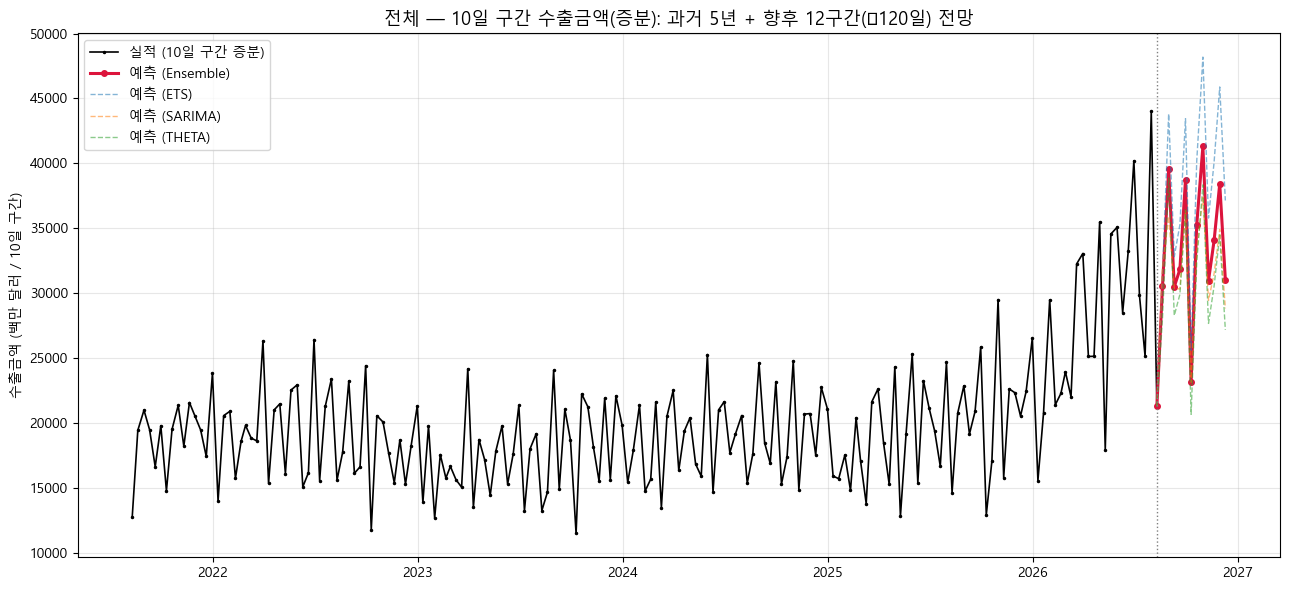

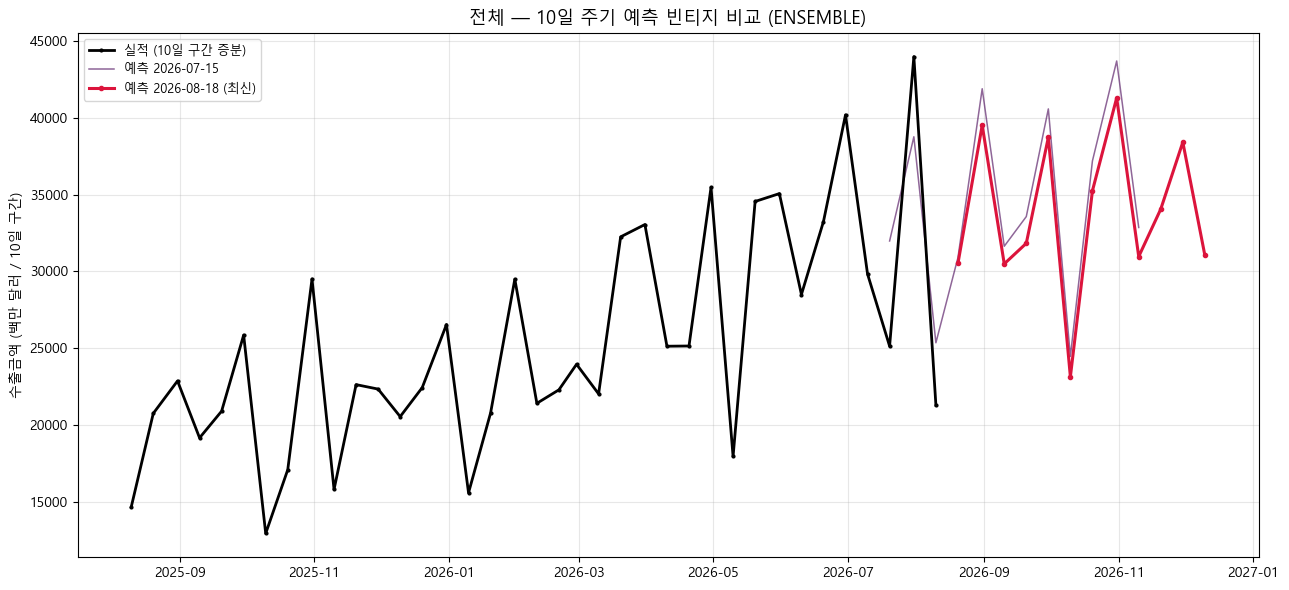

In [16]:
# 저장된 품목 확인
items_in_db = sorted(pd.read_sql(
    text(f"SELECT DISTINCT item_name FROM {ACTUAL_TABLE}"), engine
)["item_name"].tolist())
print("DB 품목:", items_in_db)

# 대표 품목: 전체수출 성격의 품목명을 우선 선택, 없으면 첫 품목
_default = next((x for x in items_in_db if ("전체" in x or "총" in x)), items_in_db[0])

plot_history_and_forecast(_default)
plot_forecast_vintages(_default)

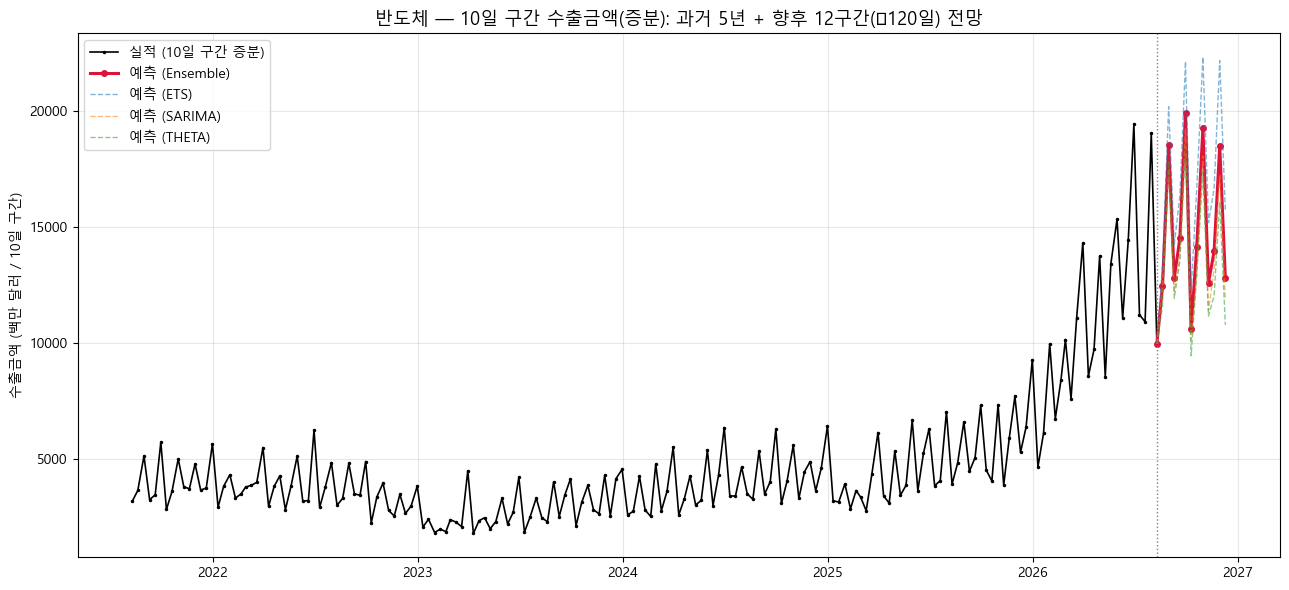

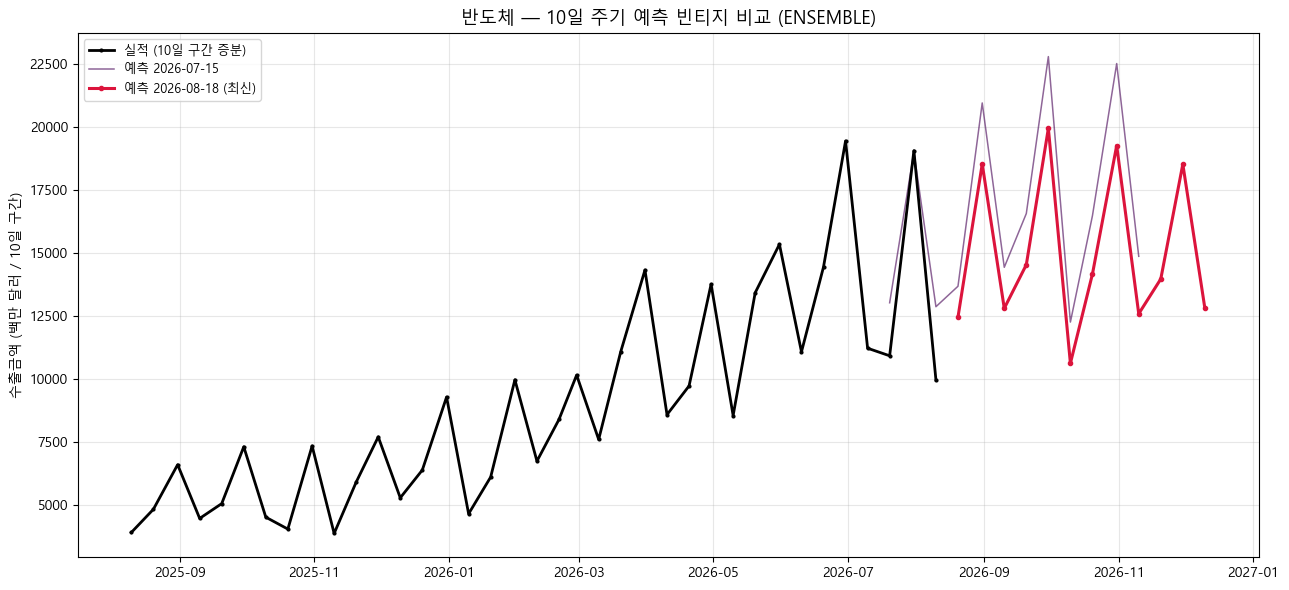

In [17]:
# 개별 품목 확인 (품목명은 위 "DB 품목" 출력에서 복사)
plot_history_and_forecast("반도체")
plot_forecast_vintages("반도체")